# MacroMind — Recipe Processing & Embedding
**Contributor: Lin Iyu** — `iylin@berkeley.edu`

This notebook covers:
1. Recipe data loading and schema inspection
2. Text preparation for embedding
3. Macro computation from USDA cache
4. Embedding with `all-MiniLM-L6-v2`
5. ChromaDB indexing and semantic search validation

In [1]:

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

load_dotenv("../.env")

from src.config import RECIPES_PATH, USDA_CACHE_PATH, EMBEDDING_MODEL, CHROMA_DB_PATH, CHROMA_COLLECTION_NAME
from src.data_pipeline import load_cache, NutritionFacts
from src.recipe_processor import load_recipes, recipe_to_document, compute_recipe_macros, build_chroma_index
from src.retriever import get_or_create_collection, collection_is_populated, semantic_search

print("✓ Imports OK")
print(f"Embedding model: {EMBEDDING_MODEL}")

/Users/janniknoahbaier/Documents/Berkeley/290 GenAI/MacroMind/MacroMind/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports OK
Embedding model: all-MiniLM-L6-v2


## 1. Load Recipe Data

In [2]:
recipes = load_recipes(RECIPES_PATH)
print(f"Loaded {len(recipes)} recipes from {RECIPES_PATH}")

# Inspect schema
r = recipes[0]
print(f"\nExample recipe: {r.name}")
print(f"  ID: {r.id}")
print(f"  Tags: {r.tags}")
print(f"  Servings: {r.servings}")
print(f"  Prep time: {r.prep_time_min} min")
print(f"  Est. cost: ${r.estimated_cost_usd}")
print(f"  Ingredients ({len(r.ingredients)}):")
for ing in r.ingredients:
    print(f"    {ing['name']}: {ing['grams']}g")
print(f"  Instructions (first 80 chars): {r.instructions[:80]}...")

Loaded 65 recipes from /Users/janniknoahbaier/Documents/Berkeley/290 GenAI/MacroMind/MacroMind/data/recipes/sample_recipes.json

Example recipe: Grilled Chicken Rice Bowl
  ID: r001
  Tags: ['high-protein', 'meal-prep', 'gluten-free']
  Servings: 1
  Prep time: 25 min
  Est. cost: $3.5
  Ingredients (4):
    chicken breast: 150g
    brown rice: 120g
    broccoli: 80g
    olive oil: 10g
  Instructions (first 80 chars): Season chicken with salt and pepper. Grill on medium-high heat 6 min per side. C...


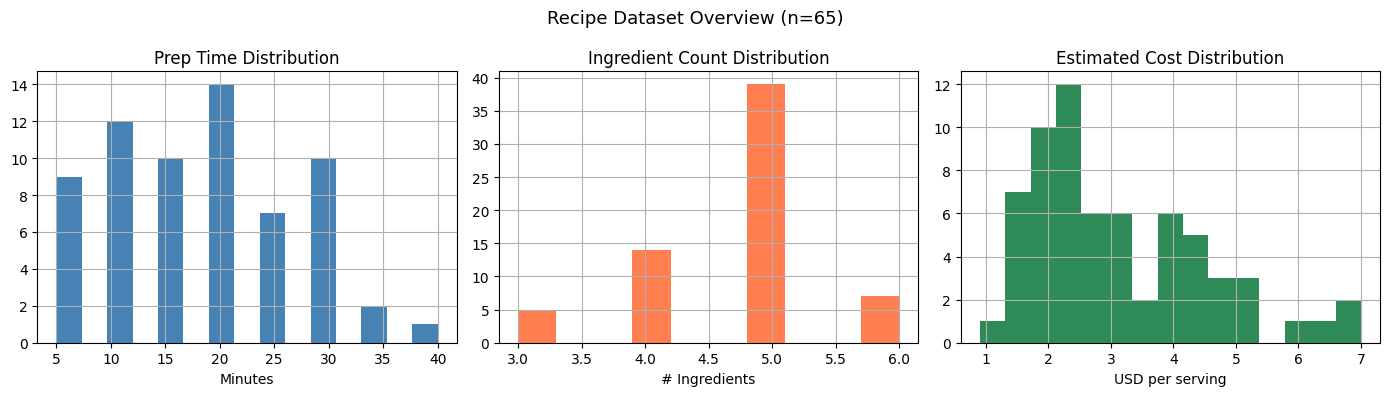


Top 15 tags:
  gluten-free: 46
  high-protein: 44
  vegetarian: 33
  budget: 23
  quick: 19
  breakfast: 19
  meal-prep: 13
  low-carb: 13
  vegan: 12
  balanced: 8
  snack: 7
  keto: 6
  omega-3: 4


In [3]:
# Distribution of recipe attributes
df_recipes = pd.DataFrame([
    {
        'name': r.name,
        'prep_time': r.prep_time_min,
        'n_ingredients': len(r.ingredients),
        'cost': r.estimated_cost_usd,
        'tags': len(r.tags)
    }
    for r in recipes
])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df_recipes['prep_time'].hist(bins=15, ax=axes[0], color='steelblue')
axes[0].set_title('Prep Time Distribution')
axes[0].set_xlabel('Minutes')

df_recipes['n_ingredients'].hist(bins=10, ax=axes[1], color='coral')
axes[1].set_title('Ingredient Count Distribution')
axes[1].set_xlabel('# Ingredients')

df_recipes['cost'].hist(bins=15, ax=axes[2], color='seagreen')
axes[2].set_title('Estimated Cost Distribution')
axes[2].set_xlabel('USD per serving')

plt.suptitle('Recipe Dataset Overview (n=65)', fontsize=13)
plt.tight_layout()
plt.show()

# Tag frequency
from collections import Counter
all_tags = [tag for r in recipes for tag in r.tags]
tag_counts = Counter(all_tags)
print("\nTop 15 tags:")
for tag, count in tag_counts.most_common(15):
    print(f"  {tag}: {count}")

## 2. Text Preparation for Embedding

Converting structured recipe data to natural language produces significantly better semantic search results than embedding raw JSON. The key insight: embedding models are trained on text corpora, so text form retrieves better.

In [4]:
# Show the document form for 3 representative recipes
sample_indices = [0, 22, 35]  # high-protein, vegetarian, balanced

for i in sample_indices:
    r = recipes[i]
    doc = recipe_to_document(r)
    print(f"--- {r.name} ---")
    print(doc)
    print()

--- Grilled Chicken Rice Bowl ---
Grilled Chicken Rice Bowl. Ingredients: chicken breast, brown rice, broccoli, olive oil. Tags: high-protein, meal-prep, gluten-free. Prep time: 25 minutes. Estimated cost: $3.50 per serving.

--- Tofu Stir-Fry with Brown Rice ---
Tofu Stir-Fry with Brown Rice. Ingredients: tofu, brown rice, broccoli, garlic, olive oil. Tags: vegetarian, vegan, high-protein, gluten-free. Prep time: 25 minutes. Estimated cost: $3.00 per serving.

--- Chicken Burrito Bowl ---
Chicken Burrito Bowl. Ingredients: chicken breast, white rice, black beans, avocado, tomato, onion. Tags: high-protein, balanced, gluten-free. Prep time: 25 minutes. Estimated cost: $4.80 per serving.



## 3. Macro Computation

We compute each recipe's total macros by summing per-ingredient contributions using the USDA nutrition cache.

In [5]:
cache = load_cache(USDA_CACHE_PATH)
nutrition_cache = {name: NutritionFacts.from_dict(data) for name, data in cache.items()}
print(f"Loaded nutrition cache: {len(nutrition_cache)} ingredients")

# Compute macros for all recipes
macro_rows = []
for r in recipes:
    m = compute_recipe_macros(r, nutrition_cache)
    macro_rows.append({
        'Recipe': r.name,
        'Calories': m.calories,
        'Protein (g)': m.protein_g,
        'Carbs (g)': m.carbs_g,
        'Fat (g)': m.fat_g,
        'Cost ($)': m.cost_usd,
    })

macro_df = pd.DataFrame(macro_rows)
print("\nMacro profile for first 10 recipes:")
display(macro_df.head(10).round(1))
print(f"\nAggregate stats:")
display(macro_df[['Calories','Protein (g)','Carbs (g)','Fat (g)','Cost ($)']].describe().round(1))

Loaded nutrition cache: 30 ingredients

Macro profile for first 10 recipes:


,Recipe,Calories,Protein (g),Carbs (g),Fat (g),Cost ($)
0,Grilled Chicken Rice Bowl,554.8,41.4,59.0,16.4,0.8
1,Tuna Salad Wrap,313.6,40.2,29.8,3.3,0.6
2,Salmon with Quinoa and Spinach,655.7,41.7,45.6,34.1,1.8
3,Greek Yogurt Parfait,344.8,28.0,52.0,3.8,0.6
4,Egg White Omelette,334.1,24.9,7.8,22.4,0.6
5,Turkey and Black Bean Burrito Bowl,632.8,35.0,74.6,20.5,0.9
6,Cottage Cheese Bowl with Banana,377.7,28.4,50.7,7.0,0.5
7,Chicken and Sweet Potato Hash,391.2,31.6,36.0,13.6,0.8
8,Chicken Caesar Salad,416.2,41.6,3.9,25.9,0.9
9,Beef and Broccoli Stir-Fry,629.6,30.7,55.7,30.4,0.9



Aggregate stats:


,Calories,Protein (g),Carbs (g),Fat (g),Cost ($)
count,65.0,65.0,65.0,65.0,65.0
mean,484.6,31.0,45.9,20.2,0.8
std,124.9,10.7,26.5,8.8,0.3
min,194.5,13.0,3.9,3.3,0.3
25%,397.5,22.5,27.1,13.6,0.6
50%,493.9,28.4,44.9,21.3,0.7
75%,593.6,39.2,63.2,26.4,0.9
max,801.5,61.2,107.4,38.1,1.8


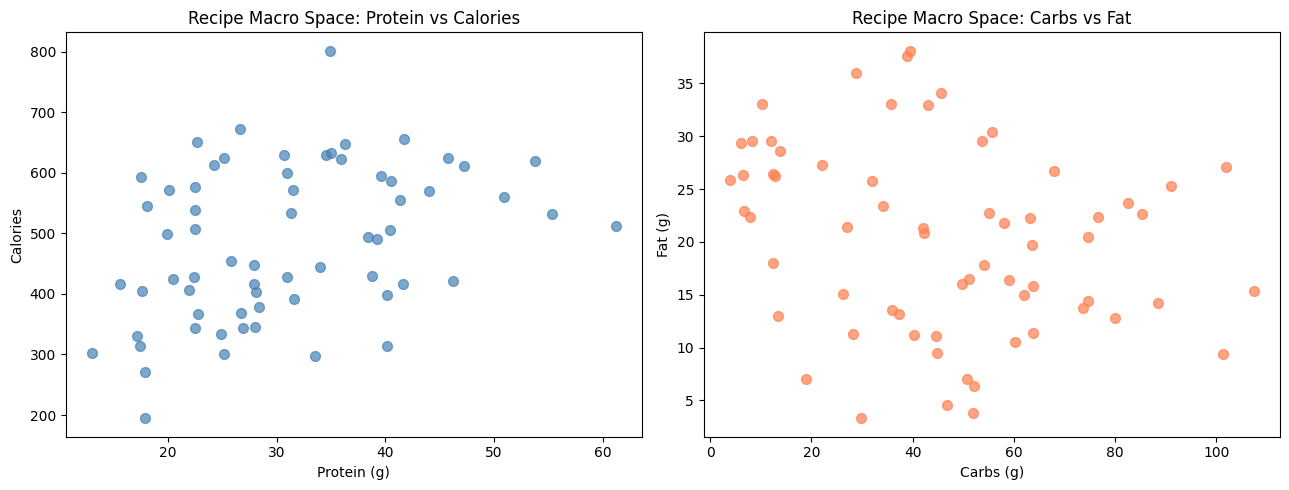

In [6]:
# Macro distribution scatter: protein vs calories
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(macro_df['Protein (g)'], macro_df['Calories'], alpha=0.7, s=50, c='steelblue')
axes[0].set_xlabel('Protein (g)')
axes[0].set_ylabel('Calories')
axes[0].set_title('Recipe Macro Space: Protein vs Calories')

axes[1].scatter(macro_df['Carbs (g)'], macro_df['Fat (g)'], alpha=0.7, s=50, c='coral')
axes[1].set_xlabel('Carbs (g)')
axes[1].set_ylabel('Fat (g)')
axes[1].set_title('Recipe Macro Space: Carbs vs Fat')

plt.tight_layout()
plt.show()

## 4. Embedding with sentence-transformers

`all-MiniLM-L6-v2` produces 384-dimensional dense embeddings. It is small (22MB), fast on CPU, and performs well for semantic similarity tasks.

In [7]:
print(f"Loading embedding model: {EMBEDDING_MODEL}")
model = SentenceTransformer(EMBEDDING_MODEL)
print(f"✓ Model loaded")
print(f"  Max sequence length: {model.max_seq_length}")
print(f"  Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading embedding model: all-MiniLM-L6-v2
✓ Model loaded
  Max sequence length: 256
  Embedding dimension: 384


In [8]:
# Embed 5 sample recipes and inspect
sample_recipes = recipes[:5]
sample_docs = [recipe_to_document(r) for r in sample_recipes]
embeddings = model.encode(sample_docs)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each vector: {embeddings[0].shape} float32 values")
print(f"L2 norm of first embedding: {np.linalg.norm(embeddings[0]):.4f} (should be ~1.0 for normalized)")

Embedding shape: (5, 384)
Each vector: (384,) float32 values
L2 norm of first embedding: 1.0000 (should be ~1.0 for normalized)


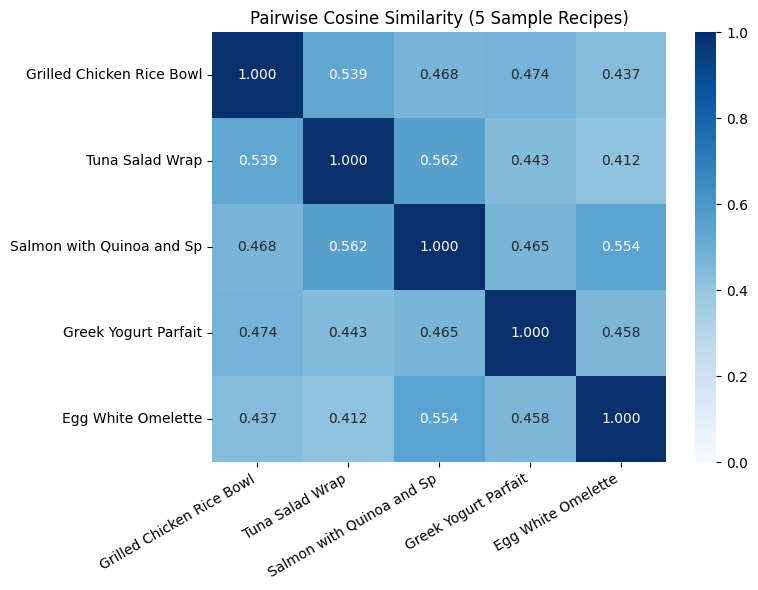

Diagonal = 1.0 (self-similarity). High off-diagonal = semantically similar recipes.


In [9]:
# Pairwise cosine similarity heatmap for 5 sample recipes
sim_matrix = cosine_similarity(embeddings)
labels = [r.name[:25] for r in sample_recipes]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Pairwise Cosine Similarity (5 Sample Recipes)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print("Diagonal = 1.0 (self-similarity). High off-diagonal = semantically similar recipes.")

## 5. ChromaDB Indexing

In [10]:
collection = get_or_create_collection(CHROMA_DB_PATH, CHROMA_COLLECTION_NAME)

if collection_is_populated(collection):
    print(f"Collection already has {collection.count()} recipes — skipping re-indexing.")
    print("(Delete data/chroma_db/ to force re-index)")
else:
    print("Building ChromaDB index from scratch...")
    build_chroma_index(recipes, collection, model, nutrition_cache)

print(f"\n✓ Collection '{CHROMA_COLLECTION_NAME}' has {collection.count()} documents")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Building ChromaDB index from scratch...


Batches: 100%|█████████████████████████████████████████| 3/3 [00:02<00:00,  1.38it/s]

Indexed 65 recipes into ChromaDB.

✓ Collection 'macromind_recipes' has 65 documents


## 6. Semantic Search Validation

We validate embedding quality by checking that semantically meaningful queries return relevant recipes.

In [11]:
test_queries = [
    ("high protein chicken rice meal prep", "Should return chicken + rice dishes"),
    ("vegan budget legumes", "Should return lentil/bean dishes"),
    ("keto low carb breakfast eggs avocado", "Should return keto-tagged breakfast recipes"),
    ("omega-3 fish salad", "Should return salmon/tuna dishes"),
    ("quick snack protein yogurt", "Should return yogurt/smoothie recipes"),
]

for query, expectation in test_queries:
    results = semantic_search(query, collection, model, n_results=3)
    print(f"\nQuery: '{query}'")
    print(f"Expected: {expectation}")
    print("Top 3 results:")
    for i, r in enumerate(results, 1):
        print(f"  {i}. {r.name} (score: {r.score:.4f}) | tags: {r.metadata.get('tags','').replace('|',', ')}")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Query: 'high protein chicken rice meal prep'
Expected: Should return chicken + rice dishes
Top 3 results:
  1. Slow Cooker Chicken and Rice (score: 0.4309) | tags: high-protein, meal-prep, gluten-free
  2. Grilled Chicken Rice Bowl (score: 0.4344) | tags: high-protein, meal-prep, gluten-free
  3. Spicy Chicken and Rice (score: 0.4769) | tags: high-protein, gluten-free, budget

Query: 'vegan budget legumes'
Expected: Should return lentil/bean dishes
Top 3 results:
  1. Rice and Beans (score: 0.3771) | tags: vegetarian, vegan, budget, gluten-free
  2. Chickpea and Spinach Sauté (score: 0.4437) | tags: vegetarian, vegan, gluten-free, budget, quick
  3. Lentil and Spinach Stew (score: 0.4453) | tags: vegetarian, vegan, high-protein, gluten-free, budget

Query: 'keto low carb breakfast eggs avocado'
Expected: Should return keto-tagged breakfast recipes
Top 3 results:
  1. Bacon Egg Avocado Bowl (score: 0.3757) | tags: keto, low-carb, breakfast, gluten-free
  2. Avocado Egg Toast (score: 0.

## 7. Index Persistence Demo

ChromaDB uses SQLite under the hood. The index persists between Python sessions.

In [12]:
# Verify persistence by creating a fresh client
import chromadb
client2 = chromadb.PersistentClient(path=CHROMA_DB_PATH)
coll2 = client2.get_collection(CHROMA_COLLECTION_NAME)
print(f"Fresh client sees {coll2.count()} documents — persistence confirmed ✓")

# Show stored metadata fields
sample = coll2.get(limit=1, include=["metadatas"])
print("\nStored metadata fields:")
for key in sample['metadatas'][0].keys():
    print(f"  {key}: {sample['metadatas'][0][key]}")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Fresh client sees 65 documents — persistence confirmed ✓

Stored metadata fields:
  calories: 554.8
  carbs: 59.0
  cost_usd: 0.8
  fat: 16.4
  ingredients: chicken breast|brown rice|broccoli|olive oil
  name: Grilled Chicken Rice Bowl
  prep_time: 25
  protein: 41.4
  recipe_id: r001
  tags: high-protein|meal-prep|gluten-free


## Summary

| Step | Details |
|------|----------|
| Dataset | 65 recipes, 30 USDA-verified ingredients |
| Text form | `name + ingredients + tags + prep + cost` |
| Embedding | `all-MiniLM-L6-v2`, 384-dim, cosine space |
| Vector DB | ChromaDB (PersistentClient, HNSW index) |
| Metadata | macros, cost, tags, ingredients stored per recipe |
| Validation | 5 semantic queries return expected recipe types |

**Key design choices:**
- Natural language document form beats raw JSON for embedding quality
- Metadata stored alongside vectors allows post-retrieval filtering without re-fetching
- Persisted index means notebooks 1 and 4 don't need to re-index